# Machine Learning for Hydrologic Parameter Estimation

This notebook details the final stage of our project: the development, evaluation, and selection of machine learning models to predict the ModClark hydrologic parameters, Time of Concentration ($T_c$) and Storage Coefficient ($R$), from watershed geomorphological and land use characteristics.

Building upon the Exploratory Data Analysis (EDA) conducted previously ([see notebook here](15_exploratory_data_analysis.ipynb)), this notebook implements the machine learning workflow. We will train and compare a suite of models, ranging from interpretable linear regressions to powerful non-linear ensembles. The ultimate goal is to identify the best-performing model that can accurately and reliably estimate $T_c$ and $R$ for ungauged basins, providing a valuable tool for hydrological modeling.

## Modeling Strategy

The insights from our EDA directly inform a clear and targeted modeling strategy. The key decisions are outlined below:

* **Target Variable Transformation:** The EDA revealed that the target variables, $T_c$ and $R$, are right-skewed and their relationships with many features are non-linear. Therefore, to improve model performance and better satisfy the assumptions of linear models, we will model the **natural logarithm** of the targets: **$\log(T_c)$** and **$\log(R)$**.

* **Tailored Feature Preprocessing:** Our EDA showed that linear models require feature transformations to meet linearity assumptions, while non-linear models do not. Therefore, we will create two separate preprocessing pipelines:
    1.  **Pipeline for Linear Models (OLS, Elastic Net):** This pipeline will include the **feature transformations** (Log/Box-Cox) suggested by the bivariate analysis, followed by **Z-score standardization**.
    2.  **Pipeline for Non-Linear Models (Random Forest, SVM):** This pipeline will only perform **Z-score standardization**. While not strictly necessary for Random Forests, it is essential for SVM and ensures consistency.

* **Feature Selection Strategy:** To create more parsimonious and interpretable models, we will incorporate feature selection:
    * **For Linear Models:** For standard linear regression, we will drop small coefficients. For elastic net regression we will leverage the **L1 regularization component of Elastic Net** as our primary method for feature selection. By tuning its strength, the model will automatically drive the coefficients of less important or redundant features to zero, effectively selecting a simpler feature subset.
    * **For Non-Linear Models:** While models like Random Forest are robust to irrelevant features, feature selection can still improve performance and interpretability. We will use the **feature importances generated by an initial Random Forest** run to guide the selection of a more focused feature set if necessary.

## Model Training and Evaluation Workflow

We will follow a, multi-step process to ensure our model evaluation is unbiased and reliable. Two separate modeling pipelines will be developed, one for predicting $\log(T_c)$ and one for $\log(R)$.

1.  **Data Splitting:** The dataset will first be split into a **training/validation pool (80% of watersheds)** and a final **hold-out test set (20% of watersheds)**. This split will be performed based on `ws_id` to ensure that all data points from a single watershed reside in only one set, preventing data leakage.

2.  **Pipeline Construction:** For each model, we will use `scikit-learn`'s `Pipeline` object, incorporating the appropriate preprocessing steps (Transformation + Scaling for linear, Scaling only for non-linear).

3.  **Model Selection via Cross-Validation:** We will use **Group K-Fold Cross-Validation** on the training/validation pool, using `ws_id` as the grouping variable. Each of our candidate models—**Multiple Linear Regression, Elastic Net, SVM, and Random Forest**—will be trained and evaluated across all folds. This process will allow us to reliably compare their performance.

4.  **Final Model Training:** After identifying the best-performing model from cross-validation, it will be re-trained one last time on the **entire training/validation pool**.

5.  **Final Evaluation:** This final, retrained model will be evaluated on the **untouched hold-out test set** to provide the definitive, unbiased assessment of its ability to generalize to new, unseen watersheds.

### Performance Metrics
The models will be compared using a standard set of regression and hydrological metrics, including:
* **Root Mean Squared Error (RMSE)**
* **Nash-Sutcliffe Efficiency (NSE)**
* **Mean Absolute Percentage Error (MAPE) of Peak Flow**
* **Bias of Peak Flow**
* **Mean Absolute Error (MAE) of Time to Peak**
* **Bias of Total Volume**

**Note**:

Before running this notebook, a preprocess step was taken to compute and save the cell area for each watershed. The source file is [available here](../../src/hydrology/compute_cell_area.py).

In [1]:
# Set root folder for the project
from pathlib import Path

# Custom Modules
PROJECT_ROOT = Path.cwd().parent.parent

In [6]:
# Load dataframes
import pandas as pd
df_master_path = PROJECT_ROOT / "data/gold/tabular/machine_learning/df_master.csv"
df_recommendations_path = PROJECT_ROOT / "data/gold/tabular/machine_learning/feature_transformation_recommendations.csv"

df_master = pd.read_csv(df_master_path, dtype={'ws_id':str})
df_recommendations = pd.read_csv(df_recommendations_path)

### 1. Data Splitting

In [3]:
import pandas as pd
import numpy as np

# --- Assume df_master is a pre-existing pandas DataFrame ---
# It must contain a 'ws_id' column.

#-------------------------------------------------------------------------------
## 1. Data Splitting (Group-Based)
#-------------------------------------------------------------------------------

print("--- Splitting data into Training Pool and Hold-Out Test Set ---")

# 1. Get a list of unique watershed IDs
unique_ws_ids = df_master['ws_id'].unique()
np.random.seed(42) # for reproducibility
np.random.shuffle(unique_ws_ids)

# 2. Split the list of watershed IDs into 80% and 20%
split_index = int(len(unique_ws_ids) * 0.8)
train_pool_ws_ids = unique_ws_ids[:split_index]
test_set_ws_ids = unique_ws_ids[split_index:]

# 3. Create the dataframes based on the split IDs
df_train_pool = df_master[df_master['ws_id'].isin(train_pool_ws_ids)].copy()
df_test = df_master[df_master['ws_id'].isin(test_set_ws_ids)].copy()


# --- Summary of the Split ---
print("\n--- Split Summary ---")
print(f"Total unique watersheds: {len(unique_ws_ids)}")
print(f"Watersheds in Training/Validation Pool: {len(train_pool_ws_ids)} (~80%)")
print(f"Watersheds in Hold-Out Test Set: {len(test_set_ws_ids)} (~20%)")
print("-" * 30)
print(f"Total data points: {len(df_master)}")
print(f"Data points in Training/Validation Pool: {len(df_train_pool)}")
print(f"Data points in Hold-Out Test Set: {len(df_test)}")

# Verify that there are no overlapping watersheds between the two sets
assert len(np.intersect1d(train_pool_ws_ids, test_set_ws_ids)) == 0
print("\nVerification successful: No watershed overlap between sets. ✅")

--- Splitting data into Training Pool and Hold-Out Test Set ---

--- Split Summary ---
Total unique watersheds: 112
Watersheds in Training/Validation Pool: 89 (~80%)
Watersheds in Hold-Out Test Set: 23 (~20%)
------------------------------
Total data points: 292
Data points in Training/Validation Pool: 226
Data points in Hold-Out Test Set: 66

Verification successful: No watershed overlap between sets. ✅


### 2. Pipeline Constructor

In [35]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PowerTransformer, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin

# --- Assume df_master, and df_recommendations are pre-existing ---

#-------------------------------------------------------------------------------
## 2. Pipeline Construction (Dynamic and Robust to Zeros)
#-------------------------------------------------------------------------------

# --- Define custom classes and functions for robust transformations ---

def log_transform_safe(x):
    """Adds a small constant to handle log(0) issues."""
    epsilon = 1e-6
    return np.log(x + epsilon)

class SafePowerTransformer(BaseEstimator, TransformerMixin):
    """
    A wrapper for PowerTransformer that adds a small constant to handle
    zero values before applying the Box-Cox transformation.
    """
    def __init__(self, method='box-cox', standardize=True):
        self.method = method
        self.standardize = standardize
        self.epsilon = 1e-6
        self.transformer_ = PowerTransformer(method=self.method, standardize=self.standardize)

    def fit(self, X, y=None):
        # Shift data by epsilon before fitting
        X_shifted = X + self.epsilon
        self.transformer_.fit(X_shifted)
        return self

    def transform(self, X):
        # Shift data by epsilon before transforming
        X_shifted = X + self.epsilon
        return self.transformer_.transform(X_shifted)

# --- Main pipeline creation function ---

print("--- Building Dynamic Preprocessing Pipelines Based on Recommendations ---")

def create_preprocessor_for_target(target_name, recommendations_df, feature_list):
    """Builds a preprocessing pipeline for a specific target variable."""

    rec_target = recommendations_df[recommendations_df['Target'] == target_name]

    log_features = [f for f in rec_target[rec_target['Best_Transform_Type'] == 'Log(x)']['Feature'].tolist() if f in feature_list]
    boxcox_features = [f for f in rec_target[rec_target['Best_Transform_Type'] == 'Box-Cox(x)']['Feature'].tolist() if f in feature_list]

    transformer_steps = []
    if log_features:
        transformer_steps.append(
            ('log', FunctionTransformer(log_transform_safe), log_features)
        )
    if boxcox_features:
        # Use the new SafePowerTransformer to handle potential zeros
        transformer_steps.append(
            ('power', SafePowerTransformer(method='box-cox'), boxcox_features)
        )

    feature_transformer = ColumnTransformer(
        transformers=transformer_steps,
        remainder='passthrough'
    )

    preprocessor_pipeline = Pipeline(steps=[
        ('feature_transformer', feature_transformer),
        ('scaler', StandardScaler())
    ])
    
    return preprocessor_pipeline

# --- Create the specific pipelines for TC and R ---
col_names = df_master.columns.tolist()
remove_cols = ['ws_id','year','tc','r']
features_to_analyze = [f for f in col_names if f not in remove_cols]
linear_preprocessor_tc = create_preprocessor_for_target('TC', df_recommendations, features_to_analyze)
linear_preprocessor_r = create_preprocessor_for_target('R', df_recommendations, features_to_analyze)


# --- Summary of Linear Pipelines ---
print("\n✅ Pipeline for Target 'TC' ('linear_preprocessor_tc') created:")
print(linear_preprocessor_tc)

print("\n✅ Pipeline for Target 'R' ('linear_preprocessor_r') created:")
print(linear_preprocessor_r)

#-------------------------------------------------------------------------------
## 2.2 Pipeline for Non-Linear Models (Random Forest, SVM)
#-------------------------------------------------------------------------------

# This pipeline only scales the features, as transformations for linearity
# are not required for these models. Scaling is still essential for SVM.
nonlinear_preprocessor = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# --- Summary of Non-Linear Pipeline ---
print("\n✅ Pipeline for Non-Linear Models ('nonlinear_preprocessor') created:")
print(nonlinear_preprocessor)

--- Building Dynamic Preprocessing Pipelines Based on Recommendations ---

✅ Pipeline for Target 'TC' ('linear_preprocessor_tc') created:
Pipeline(steps=[('feature_transformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('log',
                                                  FunctionTransformer(func=<function log_transform_safe at 0x138b6d760>),
                                                  ['sinuosity', 'pct_barren']),
                                                 ('power',
                                                  SafePowerTransformer(),
                                                  ['basin_area',
                                                   'centroidal_flowpath',
                                                   'main_channel_slope',
                                                   'flowpath_1085_slope',
                                                   'compactness_coefficient',
      

## 3. Model e Evaluation
### 3.1 Multiple Linear Regression

#### $T_c$ - Time of Concentration

In [49]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# --- Assume df_train_pool, df_test, features_to_analyze, ---
# --- linear_preprocessor_tc, and linear_preprocessor_r are pre-existing. ---

#-------------------------------------------------------------------------------
## 1. Cross-Validation on the Training Pool
#-------------------------------------------------------------------------------
print("--- Running Group K-Fold Cross-Validation for Multiple Linear Regression ---")

# Define data from the training pool
X_train = df_train_pool[features_to_analyze]
groups = df_train_pool['ws_id']

# Define the cross-validation strategy
cv = GroupKFold(n_splits=5)

# Define scoring metrics
scoring_metrics = ['r2', 'neg_root_mean_squared_error', 'neg_mean_absolute_error'] # For maximizing R-squared and minimizing RMSE/MAE

target = 'tc'
# Prepare target variable (using log transform)
y_train = np.log(df_train_pool[target])

# Create the full pipeline with the preprocessor and the regressor
model_pipeline_mlr_tc = Pipeline(steps=[
    ('preprocessor', linear_preprocessor_tc),
    ('regressor', LinearRegression())
])

# Perform cross-validation
cv_scores_mlr_tc = cross_validate(model_pipeline_mlr_tc, X_train, y_train, groups=groups, cv=cv, scoring=scoring_metrics)

#-------------------------------------------------------------------------------
## 2. Final Training 
#-------------------------------------------------------------------------------
print(f"--- Fitting Multiple Linear Regression Model on  {target.upper()} ---")

# Prepare the test data
X_test = df_test[features_to_analyze]

# Prepare training and test target variables
y_train = np.log(df_train_pool[target])
y_test_log = np.log(df_test[target])
y_test_original = df_test[target]

# Create the final pipeline
final_model_pipeline_mlr_tc = Pipeline(steps=[
    ('preprocessor', linear_preprocessor_tc),
    ('regressor', LinearRegression())
])

# Train the final model on the ENTIRE training pool
final_model_pipeline_mlr_tc.fit(X_train, y_train)

# Make predictions on the test set
y_pred_log = final_model_pipeline_mlr_tc.predict(X_test)

# Inverse transform predictions back to the original scale
y_pred_original = np.exp(y_pred_log)

print("Training is complete.")


--- Running Group K-Fold Cross-Validation for Multiple Linear Regression ---
--- Fitting Multiple Linear Regression Model on  TC ---
Training is complete.


In [54]:
## Evaluation
# -------------------------------------------------------------------------------

#-------------------------------------------------------------------------------
## 1. Performance Analysis: metrics
#-------------------------------------------------------------------------------

# Cross Validation Summary
print(f"\n--- Model evaluation for target: {target.upper()} - K-Fold Cross Validation---")

# Print average scores from cross-validation
print("Average Cross-Validation Scores (on log-transformed data):")
print(f"  R-squared: {np.mean(cv_scores_mlr_tc['test_r2']):.3f}")
print(f"  RMSE: {-np.mean(cv_scores_mlr_tc['test_neg_root_mean_squared_error']):.3f}")
print(f"  MAE: {-np.mean(cv_scores_mlr_tc['test_neg_mean_absolute_error']):.3f}")

# Final Evaluation Summary
print("\n" + "="*60)

print(f"\n--- Final Evaluation on Hold Out Test Set for target: {target.upper()} ---")
# Calculate and print final metrics
print("Performance on LOG-TRANSFORMED data:")
print(f"  R-squared: {r2_score(y_test_log, y_pred_log):.3f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test_log, y_pred_log)):.3f}")
print(f"  MAE: {mean_absolute_error(y_test_log, y_pred_log):.3f}")

print("\nPerformance on ORIGINAL scale data:")
print(f"  R-squared: {r2_score(y_test_original, y_pred_original):.3f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test_original, y_pred_original)):.3f}")
print(f"  MAE: {mean_absolute_error(y_test_original, y_pred_original):.3f}")

#-------------------------------------------------------------------------------
## 1. Performance Analysis: coefficients
#-------------------------------------------------------------------------------

# 1. Extract the final step (the linear regression model)
regressor_step_mlr_tc = final_model_pipeline_mlr_tc.named_steps['regressor']

# 2. Extract the preprocessor step
preprocessor_step_mlr_tc = final_model_pipeline_mlr_tc.named_steps['preprocessor']

# 3. Get the coefficients and intercept
coefficients = regressor_step_mlr_tc.coef_
intercept = regressor_step_mlr_tc.intercept_

# 4. Get the feature names AFTER transformation from the preprocessor
# This is the crucial step to correctly match names and coefficients
try:
    # This works for ColumnTransformer
    transformed_feature_names = preprocessor_step_mlr_tc.get_feature_names_out()
except AttributeError:
    # Fallback for simpler preprocessors (like just a scaler)
    transformed_feature_names = features_to_analyze

# 5. Combine into a pandas DataFrame for easy viewing
df_coeffs = pd.DataFrame({
    'Feature': transformed_feature_names,
    'Coefficient': coefficients
})
df_coeffs['Abs_Coefficient'] = df_coeffs['Coefficient'].abs()
df_coeffs = df_coeffs.sort_values(by='Abs_Coefficient', ascending=False)


print(f"--- Model Coefficients for Target ---")
print(f"Intercept: {intercept:.4f}\n")
print(df_coeffs)


--- Model evaluation for target: TC - K-Fold Cross Validation---
Average Cross-Validation Scores (on log-transformed data):
  R-squared: -0.508
  RMSE: 0.744
  MAE: 0.558


--- Final Evaluation on Hold Out Test Set for target: TC ---
Performance on LOG-TRANSFORMED data:
  R-squared: -0.321
  RMSE: 0.543
  MAE: 0.448

Performance on ORIGINAL scale data:
  R-squared: -0.251
  RMSE: 5.679
  MAE: 4.743
--- Model Coefficients for Target ---
Intercept: 2.3972

                      Feature  Coefficient  Abs_Coefficient
16    compactness_coefficient     1.634365         1.634365
20          ruggedness_number     1.571529         1.571529
19               relief_ratio    -1.374484         1.374484
15               basin_relief    -1.238062         1.238062
7                  basin_area    -0.774048         0.774048
14                basin_slope    -0.251982         0.251982
13        flowpath_1085_slope    -0.213100         0.213100
8            drainage_density    -0.160020         0.160020


--- Visual Performance Analysis for Target: R ---


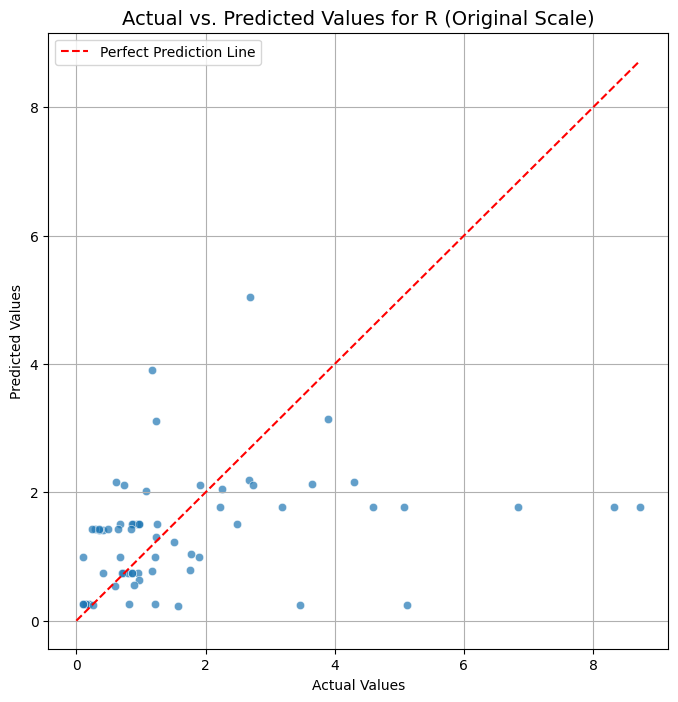


--- Checking Linear Regression Assumptions for Target: R ---


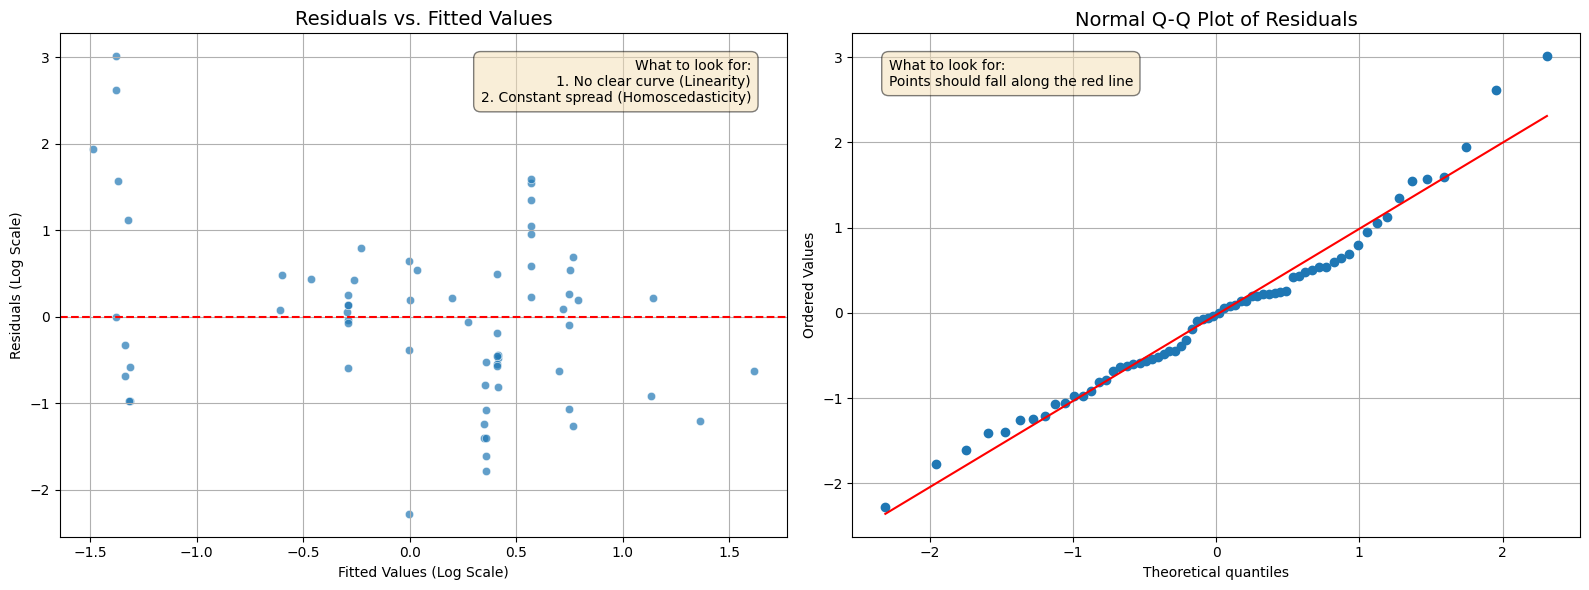

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# --- Assume final_model_pipeline, test data, and predictions exist ---

#-------------------------------------------------------------------------------
## 1. Performance Analysis: Actual vs. Predicted
#-------------------------------------------------------------------------------
print(f"--- Visual Performance Analysis for Target: {target.upper()} ---")

plt.figure(figsize=(8, 8))
sns.scatterplot(x=y_test_original, y=y_pred_original, alpha=0.7)
plt.title(f'Actual vs. Predicted Values for {target.upper()} (Original Scale)', fontsize=14)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')

# Add a 45-degree line for reference (perfect prediction)
max_val = max(y_test_original.max(), y_pred_original.max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', label='Perfect Prediction Line')

plt.legend()
plt.grid(True)
plt.show()


#-------------------------------------------------------------------------------
## 2. Assumption Checking (Residual Diagnostics)
#-------------------------------------------------------------------------------
print(f"\n--- Checking Linear Regression Assumptions for Target: {target.upper()} ---")

# Calculate residuals on the log scale the model was trained on
residuals = y_test_log - y_pred_log

# Create a figure for diagnostic plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- 2.1 Linearity and Homoscedasticity: Residuals vs. Fitted Plot ---
sns.scatterplot(x=y_pred_log, y=residuals, ax=axes[0], alpha=0.7)
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_title('Residuals vs. Fitted Values', fontsize=14)
axes[0].set_xlabel('Fitted Values (Log Scale)')
axes[0].set_ylabel('Residuals (Log Scale)')
axes[0].grid(True)
# Add interpretation text
axes[0].text(0.95, 0.95,
             'What to look for:\n1. No clear curve (Linearity)\n2. Constant spread (Homoscedasticity)',
             transform=axes[0].transAxes, fontsize=10, verticalalignment='top',
             horizontalalignment='right', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))


# --- 2.2 Normality of Errors: Q-Q Plot ---
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title('Normal Q-Q Plot of Residuals', fontsize=14)
axes[1].get_lines()[0].set_markerfacecolor('C0')
axes[1].get_lines()[0].set_markeredgecolor('C0')
axes[1].get_lines()[1].set_color('red')
axes[1].grid(True)
# Add interpretation text
axes[1].text(0.05, 0.95,
             'What to look for:\nPoints should fall along the red line',
             transform=axes[1].transAxes, fontsize=10, verticalalignment='top',
             horizontalalignment='left', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))


plt.tight_layout()
plt.show()

In [44]:
# 1. Extract the final step (the linear regression model)
regressor_step = final_model_pipeline.named_steps['regressor']

# 2. Extract the preprocessor step
preprocessor_step = final_model_pipeline.named_steps['preprocessor']

# 3. Get the coefficients and intercept
coefficients = regressor_step.coef_
intercept = regressor_step.intercept_

# 4. Get the feature names AFTER transformation from the preprocessor
# This is the crucial step to correctly match names and coefficients
try:
    # This works for ColumnTransformer
    transformed_feature_names = preprocessor_step.get_feature_names_out()
except AttributeError:
    # Fallback for simpler preprocessors (like just a scaler)
    transformed_feature_names = features_to_analyze

# 5. Combine into a pandas DataFrame for easy viewing
df_coeffs = pd.DataFrame({
    'Feature': transformed_feature_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False)
df_coeffs['Abs_Coefficient'] = df_coeffs['Coefficient'].abs()
df_coeffs = df_coeffs.sort_values(by='Abs_Coefficient', ascending=False)


print(f"--- Model Coefficients for Target: {target.upper()} ---")
print(f"Intercept: {intercept:.4f}")
display(df_coeffs)

--- Model Coefficients for Target: R ---
Intercept: 0.1732


,Feature,Coefficient,Abs_Coefficient
0,pct_developed,-58438.745383,58438.745383
1,pct_forest,58438.151558,58438.151558
19,relief_ratio,12.916523,12.916523
18,elongation_ratio,-11.515976,11.515976
7,basin_area,-3.466429,3.466429
9,stream_length,2.198893,2.198893
22,sinuosity,1.093229,1.093229
4,pct_wetlands,1.009431,1.009431
17,form_factor,-0.993231,0.993231
10,basin_length,-0.482009,0.482009


In [45]:
print(df_coeffs)

                      Feature   Coefficient  Abs_Coefficient
0               pct_developed -58438.745383     58438.745383
1                  pct_forest  58438.151558     58438.151558
19               relief_ratio     12.916523        12.916523
18           elongation_ratio    -11.515976        11.515976
7                  basin_area     -3.466429         3.466429
9               stream_length      2.198893         2.198893
22                  sinuosity      1.093229         1.093229
4                pct_wetlands      1.009431         1.009431
17                form_factor     -0.993231         0.993231
10               basin_length     -0.482009         0.482009
20          ruggedness_number     -0.446942         0.446942
2             pct_agriculture      0.343287         0.343287
16    compactness_coefficient      0.311642         0.311642
21  overland_flow_path_length      0.294141         0.294141
5                   pct_water     -0.243793         0.243793
3             pct_grass_

**Analysis of Linear Regression Coefficients for Target R**

The coefficient table provides critical insights into the model's behavior and highlights a significant issue that needs to be addressed. The intercept for this model is **0.1732**.

---
**Key Insights**

* **Severe Multicollinearity is Present:** The most striking result is the enormous and nearly equal-opposite coefficients for **`pct_developed` (-58438.7)** and **`pct_forest` (+58438.1)**. This is a classic symptom of severe multicollinearity. Because these two features are highly negatively correlated, the model cannot distinguish their individual effects. It assigns a massive negative weight to one and a massive positive weight to the other to cancel each other out. This makes the model **highly unstable**, and these specific coefficients are **not hydrologically interpretable**.

* **Basin Shape is an Important Predictor:** After the land use features, **`elongation_ratio`** has a large negative coefficient (-11.5). This is hydrologically sensible, suggesting that less elongated (i.e., more compact and circular) basins are associated with higher values of the storage coefficient `R`.

* **Counter-intuitive Effect of Relief:** The feature **`relief_ratio`** has a large positive coefficient (+12.9), suggesting that steeper watersheds have higher storage. This is counter-intuitive and is likely another artifact of the multicollinearity problem, where the model assigns a questionable coefficient to compensate for other correlated features.

* **Many Features Have Low Impact:** A large number of features have coefficients very close to zero (e.g., `basin_slope`, `main_channel_slope`, `pct_barren`), indicating they have minimal influence in this specific linear model.

---
### How to Improve the Model

The primary issue to address is multicollinearity.

1.  **Use a Regularized Model:** This is the best approach. An **Elastic Net Regression** is specifically designed for this situation. Its regularization penalty (a combination of L1 and L2 norms) will shrink the massive coefficients of correlated features, making the model more stable. The L1 component can also perform automatic feature selection by forcing the coefficients of the least important features to exactly zero.

2.  **Use a Tree-Based Model:** Models like **Random Forest** are not susceptible to multicollinearity in the same way linear models are. They are likely to produce more stable and reliable results and a more interpretable feature importance ranking.

3.  **Manual Feature Selection:** Before training, you can manually remove some of the highly redundant features that were identified in the correlation analysis during the EDA.

---
### What Variables Could Be Dropped?

Based on the model's instability and the low coefficient values, here are candidates for removal:

* **One of the Highly Correlated Land Use Features:** To fix the main instability, you should remove either `pct_developed` or `pct_forest`. An even better approach would be to replace both with your aggregated **`natural_vs_developed_ratio`** feature, which combines their effects into a single, more stable variable.

* **Redundant Geomorphological Features:** Based on the EDA, you can drop features that provide overlapping information. For example:
    * Keep `basin_area` and drop `stream_length`, `basin_length`, and `overland_flow_path_length`.
    * Keep `main_channel_slope` and drop `flowpath_1085_slope` and `relief_ratio`.
    * Keep `form_factor` and drop `elongation_ratio`.

* **Features with Near-Zero Coefficients:** These features have the least impact on this model's predictions and can be safely removed to create a simpler model. The top candidates to drop are:
    * `pct_barren`
    * `main_channel_slope`
    * `flowpath_1085_slope`
    * `basin_slope`
    * `centroidal_flowpath`